In [ ]:
# read with pandas

import pandas as pd


cols = ["[RP2006]", "F[OIII]", "e_F[OIII]", "_RA", "_DE"]
tablea1 = pd.read_csv("tablea1.csv", sep=",")
tablea2 = pd.read_csv("tablea2.csv", sep=",")

tablea2.columns
coords = pd.concat([tablea1[cols], tablea2[cols]], ignore_index=False)

coords

          _RA       _DE
0    85.63829 -70.49003
1    86.14458 -70.36133
2    84.51925 -70.49053
3    86.60537 -71.38953
4    85.15667 -70.46528
..        ...       ...
408  86.66408 -70.94725
409  87.51804 -70.67650
410  85.91162 -70.56714
411  84.56867 -70.70089
412  82.49008 -70.96700

[577 rows x 2 columns]


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

snr = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")
pnes = SkyCoord(coords["_RA"].values * u.deg, coords["_DE"].values * u.deg, frame="icrs")

pnes

<SkyCoord (ICRS): (ra, dec) in deg
    [(85.63829, -70.49003), (86.14458, -70.36133), (84.51925, -70.49053),
     (86.60537, -71.38953), (85.15667, -70.46528), (85.65265, -70.15891),
     (85.67121, -70.09697), (84.81029, -70.00517), (84.724  , -69.96536),
     (87.41146, -69.16647), (86.77   , -69.45892), (85.40254, -69.45272),
     (85.601  , -69.88475), (84.57312, -68.97961), (85.34187, -68.12894),
     (86.27487, -68.11414), (85.56421, -68.81547), (85.94829, -68.64308),
     (86.60587, -67.83411), (85.18579, -67.30214), (84.08671, -67.30208),
     (85.12832, -66.29373), (85.08392, -67.03383), (84.81396, -66.82878),
     (84.97825, -66.57017), (80.67073, -71.31855), (81.11396, -70.37325),
     (81.06537, -70.89897), (81.22948, -71.54896), (81.93242, -71.43236),
     (82.26187, -70.32356), (82.63824, -70.74374), (82.69112, -70.83789),
     (82.84122, -70.6793 ), (83.66229, -70.33208), (82.38625, -70.29417),
     (82.60946, -71.23   ), (83.62571, -70.47625), (82.14337, -70.55044),
   

In [35]:
sep = snr.separation(pnes)

fov = coords[sep < 500 * u.arcsec]

fov

,[RP2006],F[OIII],e_F[OIII],_RA,_DE
21,99,4.260000e-14,2.130000e-15,86.59979,-70.43217
22,102,7.000000e-15,3.500000e-16,87.33442,-70.46939
23,103,2.060000e-14,1.030000e-15,86.75637,-70.47847
27,122,4.290000e-15,2.150000e-16,86.86958,-70.33775


/Users/markpirgalin/anaconda3/lib/python3.11/site-packages/astropy/wcs/wcs.py:805: FITSFixedWarning: 'datfix' made the change 'Set DATE-OBS to '2020-11-12T03:31:35.772' from MJD-OBS'.
  warnings.warn(


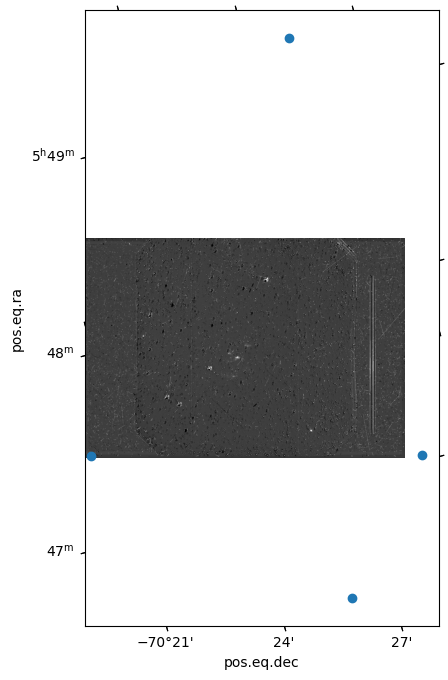

In [52]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

image = fits.open("test_sub.fits")[0].data
wcs_hdul = fits.open("images/SNR_OIII.fits")

wcs = WCS(wcs_hdul["SCI"].header)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

ax.imshow(image, origin="lower", cmap="gray", vmin=np.percentile(image,1), vmax=np.percentile(image,99.5))

ax.scatter(fov["_RA"].values *u.deg, fov["_DE"].values *u.deg, transform=ax.get_transform("world"))